# F1 — Pit Stops & Strategy (2011–2024)

Pit-stop analyses across the modern era of F1.
This notebook covers **Section 9** of `QuestionsF1.txt`.

## Questions covered
| # | Question |
|---|---|
| 9.1 | Avg pit stops per race across seasons / eras |
| 9.2 | Avg pit-stop time per season / era |
| 9.3 | Best pit-stop time per season / era |
| 9.4 | Worst pit-stop time per season / era |
| 9.5 | Change in mean pit-stop time between consecutive seasons / eras |
| 9.6 | Avg pit stops: per race vs per season |
| 9.7 | Average pit-stop time per circuit *(top 5 high / low, 2011+)* |

**Important data caveat:** the Ergast `pit_stops.csv` only goes back to **2011** — earlier pit-stop data was never digitized. So everything below lives in **Era 8 (V8 / Limited electronics, 2006–2013)** + **Era 9 (Hybrid V6 Turbo, 2014–present)**. Decade aggregations would only cover 2010s + 2020s, so they are dropped from this notebook in favour of per-era breakdowns.

Per the question header, we restrict to **cars that finished** the race — pit stops by drivers who later retired are dropped, since their stop count is incomplete.

## Setup — imports, data loading, finisher filter


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from f1_utils import (
    show_and_save, eras_df, year_to_era, apply_default_style,
)
apply_default_style()

sns.set_theme(style='whitegrid')

drivers      = pd.read_csv('excel/drivers.csv')
results      = pd.read_csv('excel/results.csv')
races        = pd.read_csv('excel/races.csv')
status       = pd.read_csv('excel/status.csv')
pit_stops    = pd.read_csv('excel/pit_stops.csv')

drivers['driver'] = drivers['surname'] + ' ' + drivers['forename'].str[0] + '.'

# Indy cleanup (Indy 500 has no pit-stop data anyway, but stay consistent)
indy_race_ids = races.loc[
    races['name'].str.contains('Indianapolis', case=False, na=False), 'raceId']
results = results[~results['raceId'].isin(indy_race_ids)].copy()
races   = races  [~races  ['raceId'].isin(indy_race_ids)].copy()

os.makedirs('charts', exist_ok=True)
def show_and_save(filename, dpi=150):
    plt.savefig(f'charts/{filename}', dpi=dpi, bbox_inches='tight')
    plt.show()


# Classified-finish set (used to keep only cars that 'finished' the race)
finished_status = status[(status['status'] == 'Finished') |
                         status['status'].str.startswith('+')]
finished_ids = set(finished_status['statusId'])

results['is_finish'] = results['statusId'].isin(finished_ids)


# Era boundaries — same as the era notebook. We need these for the
# 'per era' aggregations below.
eras_df = pd.DataFrame([
    (1, 'Pre-aerodynamic / Front-engine',     1950, 1958),
    (2, 'Rear-engine revolution',             1959, 1967),
    (3, 'Wings & aerodynamics',               1968, 1982),
    (4, 'Turbo era',                          1983, 1988),
    (5, 'Active suspension / post-turbo',     1989, 1993),
    (6, 'Driver-aid ban / pre-V10 dominance', 1994, 1999),
    (7, 'V10 era',                            2000, 2005),
    (8, 'V8 / Limited electronics',           2006, 2013),
    (9, 'Hybrid V6 Turbo',                    2014, 2025),
], columns=['era_id', 'name_en', 'year_start', 'year_end'])

def year_to_era(y):
    m = eras_df[(eras_df['year_start'] <= y) & (eras_df['year_end'] >= y)]
    return int(m['era_id'].iloc[0]) if len(m) else None


# Pit stops × races × finisher flag — only stops by cars that finished
ps = (pit_stops
      .merge(races[['raceId', 'year']], on='raceId')
      .merge(results[['raceId', 'driverId', 'is_finish']],
             on=['raceId', 'driverId']))
ps_finishers = ps[ps['is_finish']].copy()
ps_finishers['era_id'] = ps_finishers['year'].apply(year_to_era)

# Drop pit-stop rows where 'milliseconds' is missing (some early ones are NaN)
ps_finishers = ps_finishers.dropna(subset=['milliseconds'])
ps_finishers['seconds'] = ps_finishers['milliseconds'].astype(float) / 1000

print(f'Pit stops in dataset           : {len(pit_stops):,}')
print(f'Pit stops by FINISHERS only    : {len(ps_finishers):,}')
print(f'Years with pit-stop data       : {ps_finishers["year"].min()}–{ps_finishers["year"].max()}')
print(f'Min / median / max stop seconds: '
      f'{ps_finishers["seconds"].min():.2f} / '
      f'{ps_finishers["seconds"].median():.2f} / '
      f'{ps_finishers["seconds"].max():.2f}')


# Era palette — only Era 8 (V8, 2006-2013) and Era 9 (Hybrid V6, 2014+)
# actually appear in the 2011+ pit-stop window, but we keep all 9 keys
# for consistency with the era notebook.
ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#A65A2A', 9: '#1B6E4A',
}

Pit stops in dataset           : 11,371
Pit stops by FINISHERS only    : 10,169
Years with pit-stop data       : 2011–2024
Min / median / max stop seconds: 12.90 / 23.53 / 3069.02


---
### 9.1 — Avg pit stops per race across seasons / eras

Per-race count of pit stops by finishers, divided by the number of finishers in that race = "average stops per car (that finished)". Then aggregate that ratio per season / era.

The trend tells you the **strategic regime**: more stops = harder tyres / more pit-window flexibility; fewer stops = "manage to the end" eras.

Avg pit stops per finisher, per season:
 year  avg_stops  era_id
 2011   2.666949       8
 2012   2.155567       8
 2013   2.420538       8
 2014   2.230467       9
 2015   2.152700       9
 2016   2.324188       9
 2017   1.993271       9
 2018   1.431979       9
 2019   1.639191       9
 2020   2.017122       9
 2021   2.055120       9
 2022   1.995179       9
 2023   2.247395       9
 2024   1.816387       9

Per era:
 era_id                  name_en  avg_stops
      8 V8 / Limited electronics    2.40989
      9          Hybrid V6 Turbo    1.98602


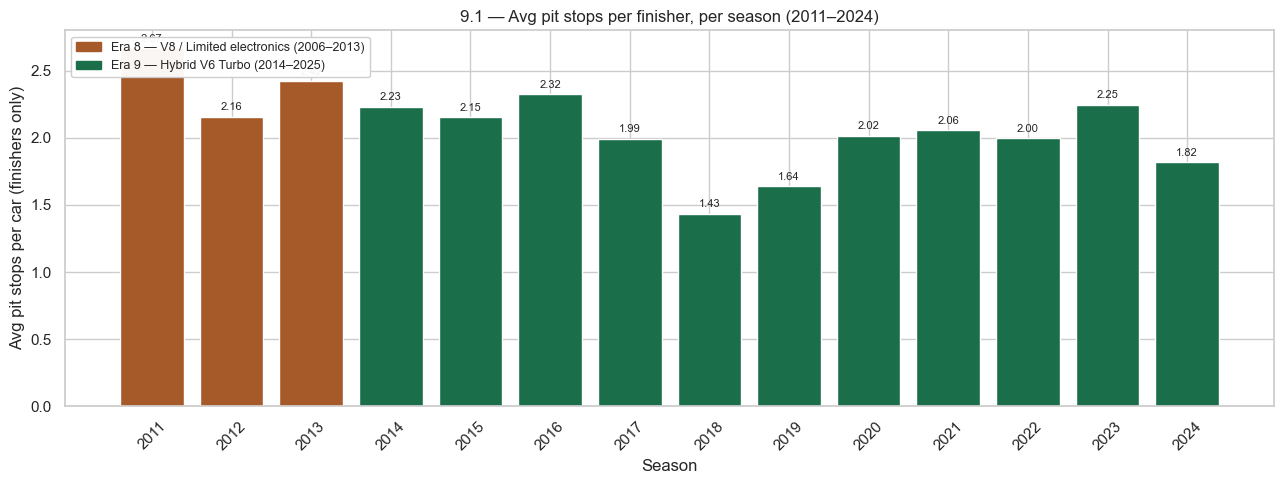

In [26]:
# Step 1 — per (race, driver) count of stops
stops_per_race_driver = (ps_finishers
                         .groupby(['raceId', 'year', 'driverId']).size()
                         .reset_index(name='stops'))

# Step 2 — per race, AVG stops across all finishing drivers
stops_per_race = (stops_per_race_driver.groupby(['raceId', 'year'])
                  ['stops'].mean()
                  .reset_index(name='avg_stops_per_finisher'))

stops_per_race['era_id'] = stops_per_race['year'].apply(year_to_era)

# Per-season average
per_season = (stops_per_race.groupby('year')['avg_stops_per_finisher']
              .mean().reset_index(name='avg_stops'))
per_season['era_id'] = per_season['year'].apply(year_to_era)
print('Avg pit stops per finisher, per season:')
print(per_season.to_string(index=False))

# Per-era
per_era = (stops_per_race.merge(eras_df[['era_id', 'name_en']], on='era_id')
           .groupby(['era_id', 'name_en'])['avg_stops_per_finisher']
           .mean().reset_index(name='avg_stops'))
print('\nPer era:')
print(per_era.to_string(index=False))


# Time series — avg stops per season, bars coloured by ERA
fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = [ERA_COLORS[e] for e in per_season['era_id']]
ax.bar(per_season['year'], per_season['avg_stops'],
       color=bar_colors, edgecolor='white')
for r in per_season.itertuples():
    ax.text(r.year, r.avg_stops + 0.05,
            f'{r.avg_stops:.2f}', ha='center', fontsize=8)

# Era legend — only show eras that actually appear in the chart
eras_in_chart = (per_season.merge(eras_df, on='era_id')
                 [['era_id', 'name_en', 'year_start', 'year_end']]
                 .drop_duplicates().sort_values('era_id'))
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=ERA_COLORS[r.era_id],
                                label=f'Era {r.era_id} — {r.name_en} ({r.year_start}–{r.year_end})')
                  for r in eras_in_chart.itertuples()]
ax.legend(handles=legend_handles, loc='upper left', fontsize=9, framealpha=0.95)

ax.set_xticks(per_season['year'])
ax.set_xticklabels(per_season['year'], rotation=45)
ax.set_title('9.1 — Avg pit stops per finisher, per season (2011–2024)')
ax.set_xlabel('Season')
ax.set_ylabel('Avg pit stops per car (finishers only)')
plt.tight_layout()
show_and_save('9.1_avg_stops_per_race.png')

**SQL equivalent**
```sql
-- 9.1: Avg pit stops per finisher, per season
WITH per_driver AS (
    SELECT  ra.year, p.raceId, p.driverId, COUNT(*) AS stops
    FROM    pit_stops p
    JOIN    races     ra ON p.raceId   = ra.raceId
    JOIN    results   r  ON p.raceId   = r.raceId AND p.driverId = r.driverId
    JOIN    status    s  ON r.statusId = s.statusId
    WHERE   ra.name NOT LIKE '%Indianapolis%'
      AND  (s.status = 'Finished' OR s.status LIKE '+%')
    GROUP   BY ra.year, p.raceId, p.driverId
),
per_race AS (
    SELECT  year, raceId, AVG(stops) AS avg_stops_per_finisher
    FROM    per_driver
    GROUP   BY year, raceId
)
SELECT  year, AVG(avg_stops_per_finisher) AS avg_stops
FROM    per_race
GROUP   BY year
ORDER   BY year;
```


---
### 9.2 – 9.4 — Avg / best / worst pit-stop time per season

Three statistics on `seconds` (= stop duration), aggregated per season + per era:
- **9.2 — Avg** — mean stop time. Sensitive to outliers (a 90-sec stop after a power steering issue inflates the mean).
- **9.3 — Best** — minimum stop time. The fastest stop ever recorded that year.
- **9.4 — Worst** — maximum stop time. Almost always a mechanical issue or wheel-not-attached drama.

To make the absolute numbers comparable, we trim wholly-implausible stops (under 1 second is a data error; over 120 s is effectively a retirement) — see the cleanup filter below.

Pit stops kept after cleanup (9,741 of 10,169)

Per season:
 year  mean_s  best_s  worst_s  stops  era_id
 2011   23.48   12.90    56.61   1000       8
 2012   23.13   13.20    52.21    842       8
 2013   23.44   13.27    74.03    852       8
 2014   24.91   16.12    78.28    697       9
 2015   25.19   16.13   107.39    643       9
 2016   24.60   16.22   104.38    806       9
 2017   24.18   14.97    51.76    578       9
 2018   24.57   15.00    56.71    475       9
 2019   24.75   15.07    69.02    571       9
 2020   25.33   16.36    52.87    492       9
 2021   25.35   14.88    86.44    636       9
 2022   24.59   13.97    50.79    689       9
 2023   24.65   16.25    76.63    741       9
 2024   24.87   15.79    93.27    719       9

Per era:
 era_id                  name_en  mean_s  best_s  worst_s  stops
      8 V8 / Limited electronics   23.36   12.90    74.03   2694
      9          Hybrid V6 Turbo   24.81   13.97   107.39   7047


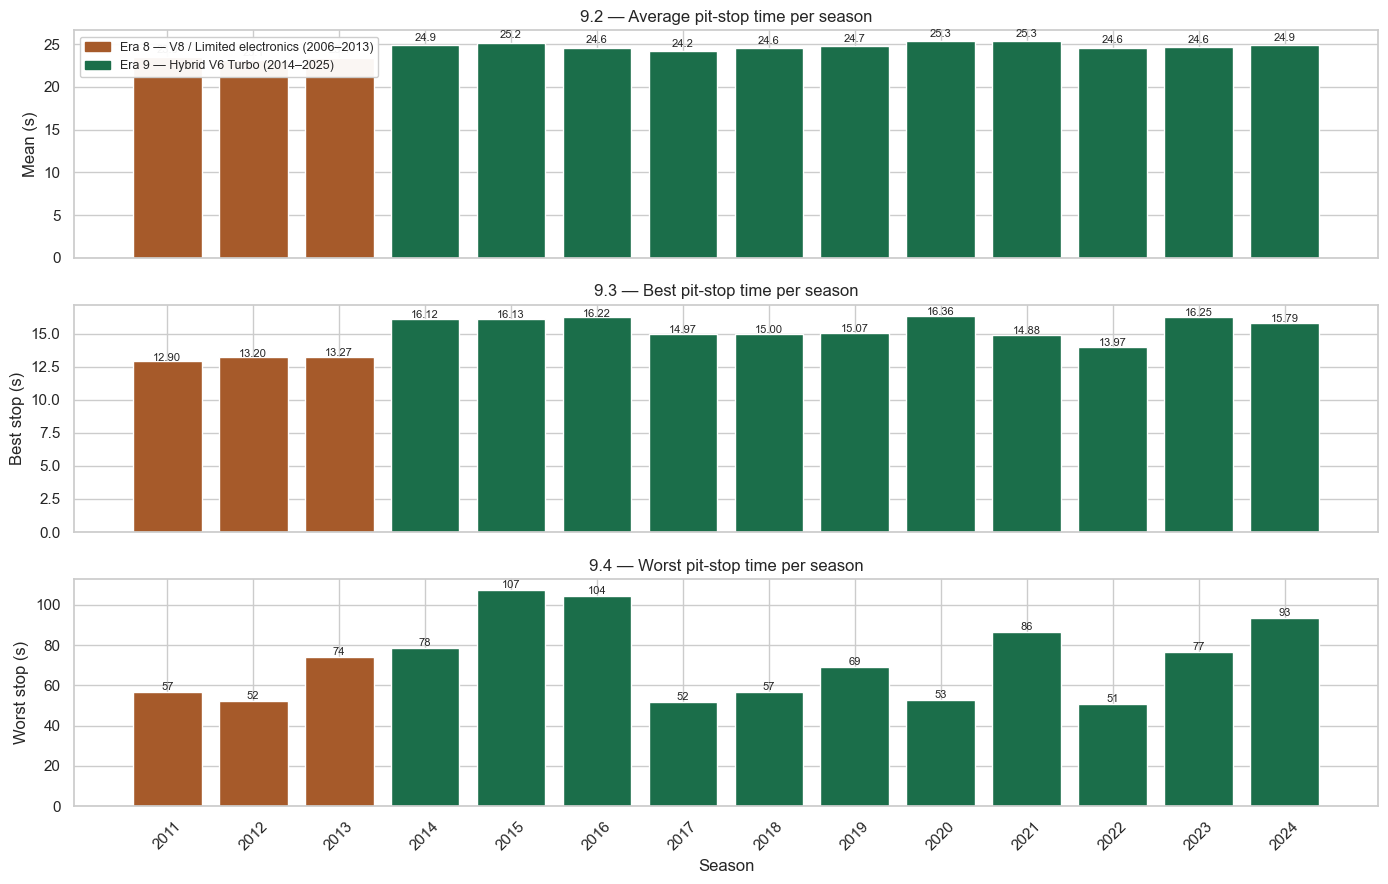

In [27]:
# Filter implausible values: <1s = data error, >120s = effective retirement
ps_clean = ps_finishers[(ps_finishers['seconds'] >= 1) &
                        (ps_finishers['seconds'] <= 120)].copy()
print(f'Pit stops kept after cleanup ({len(ps_clean):,} of {len(ps_finishers):,})')


def agg_per_year(df):
    return (df.groupby('year')
            .agg(mean_s=('seconds', 'mean'),
                 best_s=('seconds', 'min'),
                 worst_s=('seconds', 'max'),
                 stops=('seconds', 'count'))
            .reset_index())

per_year = agg_per_year(ps_clean)
per_year['era_id'] = per_year['year'].apply(year_to_era)
print('\nPer season:')
print(per_year.round(2).to_string(index=False))

per_era = (ps_clean.merge(eras_df[['era_id', 'name_en']], on='era_id')
           .groupby(['era_id', 'name_en'])
           .agg(mean_s=('seconds', 'mean'),
                best_s=('seconds', 'min'),
                worst_s=('seconds', 'max'),
                stops=('seconds', 'count'))
           .reset_index())
print('\nPer era:')
print(per_era.round(2).to_string(index=False))


# Three-panel chart — mean / min / max per season, all coloured by ERA
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

bar_colors = [ERA_COLORS[e] for e in per_year['era_id']]

axes[0].bar(per_year['year'], per_year['mean_s'], color=bar_colors, edgecolor='white')
axes[0].set_ylabel('Mean (s)')
axes[0].set_title('9.2 — Average pit-stop time per season')
for r in per_year.itertuples():
    axes[0].text(r.year, r.mean_s + 0.5, f'{r.mean_s:.1f}', ha='center', fontsize=8)

axes[1].bar(per_year['year'], per_year['best_s'], color=bar_colors, edgecolor='white')
axes[1].set_ylabel('Best stop (s)')
axes[1].set_title('9.3 — Best pit-stop time per season')
for r in per_year.itertuples():
    axes[1].text(r.year, r.best_s + 0.05, f'{r.best_s:.2f}', ha='center', fontsize=8)

axes[2].bar(per_year['year'], per_year['worst_s'], color=bar_colors, edgecolor='white')
axes[2].set_ylabel('Worst stop (s)')
axes[2].set_title('9.4 — Worst pit-stop time per season')
axes[2].set_xlabel('Season')
for r in per_year.itertuples():
    axes[2].text(r.year, r.worst_s + 1, f'{r.worst_s:.0f}', ha='center', fontsize=8)

# Per-year x-ticks on the shared axis
axes[2].set_xticks(per_year['year'])
axes[2].set_xticklabels(per_year['year'], rotation=45)

# Shared era legend on the top panel
eras_in_chart = (per_year.merge(eras_df, on='era_id')
                 [['era_id', 'name_en', 'year_start', 'year_end']]
                 .drop_duplicates().sort_values('era_id'))
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=ERA_COLORS[r.era_id],
                                label=f'Era {r.era_id} — {r.name_en} ({r.year_start}–{r.year_end})')
                  for r in eras_in_chart.itertuples()]
axes[0].legend(handles=legend_handles, loc='upper left', fontsize=9, framealpha=0.95)

plt.tight_layout()
show_and_save('9.2_9.3_9.4_pit_stop_time_summary.png')

**SQL equivalent**
```sql
-- 9.2 / 9.3 / 9.4: stats on pit-stop seconds per season (finishers only)
WITH ps_clean AS (
    SELECT  ra.year, p.milliseconds / 1000.0 AS seconds
    FROM    pit_stops p
    JOIN    races     ra ON p.raceId   = ra.raceId
    JOIN    results   r  ON p.raceId   = r.raceId AND p.driverId = r.driverId
    JOIN    status    s  ON r.statusId = s.statusId
    WHERE   ra.name NOT LIKE '%Indianapolis%'
      AND  (s.status = 'Finished' OR s.status LIKE '+%')
      AND   p.milliseconds BETWEEN 1000 AND 120000   -- 1–120 sec
)
SELECT
    year,
    AVG(seconds) AS mean_s,
    MIN(seconds) AS best_s,
    MAX(seconds) AS worst_s,
    COUNT(*)     AS stops
FROM    ps_clean
GROUP   BY year
ORDER   BY year;
```


---
### Analyst recommendations for 9.1 – 9.4

**Common caveat for all four charts.** The pit-stop dataset only begins in **2011**. So 9.1–9.4 are not really "across F1 history" — they describe the late-V8 era (2011–2013) and the Hybrid V6 era (2014+). Don't read them as long-term trends.

**9.1 — Avg pit stops per race**
- The 2-stop band (~1.8–2.5) is almost entirely a **Pirelli compound-choice artefact**, not a regulatory shift. Pirelli tunes the tyre allocation per circuit to target ~2 stops. So this chart is closer to "Pirelli's strategic intent per season" than to "team strategy".
- **Add a "mandatory stop = 1" baseline reference line** at y = 1.0 so the reader sees the gap between "the rule" and "actual behaviour".
- Consider a **second view that splits dry vs. wet races** — rain races (Brazil 2016, Spa 2021, Suzuka 2022) inflate the average and are not strategic choices.

**9.2 — Average pit-stop time**
- The "average" is misleading: a single 90-second stop after a power-steering issue lifts the season mean by ~0.5 s. **Switch to median** for the headline, keep mean as a secondary line.
- **Stationary time vs total pit-lane time matters here.** Ergast's `milliseconds` is the full pit-lane traverse, not the DHL-award "tyres-off → tyres-on" window. Add this caveat next to the chart so readers don't compare your ~24 s numbers against the sub-2-second figures they see on TV.
- Add a **horizontal min-pit-lane-speed line** (~22 s for the typical 60 km/h limit over a 400 m lane) — the gap between that line and the actual mean is the part the team controls.

**9.3 — Best pit-stop time**
- A single-stop minimum is **very noisy** — one team having a perfect Sunday distorts the season. Replace with **p5 (5th percentile)** for robustness.
- **Annotate** the bar for each year with the team that did it (Red Bull dominates 2019–2023). Without that the chart is just numbers.

**9.4 — Worst pit-stop time**
- Mostly **wheel-not-attached drama or hydraulic failure** — not a "pit-stop performance" metric, but a **reliability signal**. Rename the panel "Worst recorded stop (mechanical-failure indicator)" so readers don't misread it.
- Consider showing the **count of stops > 60 s per season** alongside — that's a more honest "how often did things go wrong" view than just the single worst value.
- The 120-second filter from cleanup drops genuine retirements; flag that in the chart subtitle.

---
### 9.5 — Change in pit-stop time between consecutive periods

Two views:
- **Year-over-year** — `mean_s[year] − mean_s[year-1]`. Negative = stops got faster (= improvement).
- **Era-over-era** — same, but on the era buckets.

Useful to see whether the speed-up was *gradual* (small YoY drops every year) or *step-changes* (one huge jump in 2014 from the V8→Hybrid transition).

Year-over-year change in mean pit-stop time:
 year  mean_s  delta_s
 2011  23.483      NaN
 2012  23.134   -0.350
 2013  23.443    0.309
 2014  24.912    1.469
 2015  25.194    0.282
 2016  24.605   -0.589
 2017  24.182   -0.423
 2018  24.573    0.391
 2019  24.749    0.176
 2020  25.326    0.577
 2021  25.348    0.022
 2022  24.593   -0.755
 2023  24.647    0.054
 2024  24.871    0.224

Era-over-era change in mean pit-stop time:
 era_id                  name_en  mean_s  delta_s
      8 V8 / Limited electronics  23.361      NaN
      9          Hybrid V6 Turbo  24.812     1.45


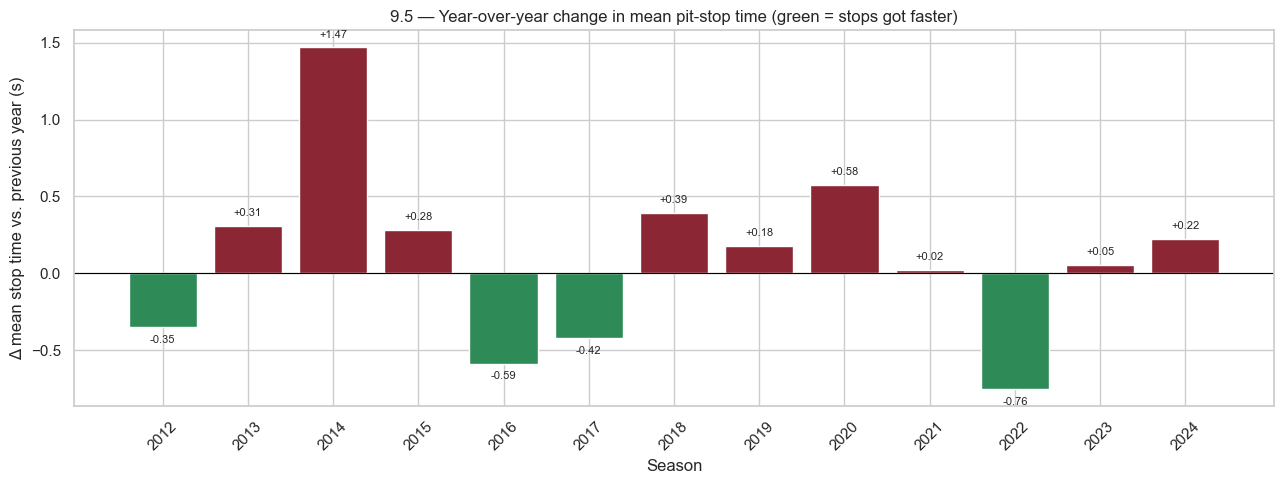

In [28]:
yoy = per_year[['year', 'mean_s']].copy()
yoy['delta_s'] = yoy['mean_s'].diff()
print('Year-over-year change in mean pit-stop time:')
print(yoy.round(3).to_string(index=False))

era_yoy = per_era[['era_id', 'name_en', 'mean_s']].copy()
era_yoy['delta_s'] = era_yoy['mean_s'].diff()
print('\nEra-over-era change in mean pit-stop time:')
print(era_yoy.round(3).to_string(index=False))


# Bar — diverging palette: green (improvement) / red (regression)
yoy_plot = yoy.dropna(subset=['delta_s']).copy()
yoy_plot['color'] = yoy_plot['delta_s'].apply(lambda x: '#2E8B57' if x < 0 else '#8B2635')

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(yoy_plot['year'], yoy_plot['delta_s'],
       color=yoy_plot['color'], edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
for r in yoy_plot.itertuples():
    sign = '' if r.delta_s < 0 else '+'
    ax.text(r.year,
            r.delta_s + (0.05 if r.delta_s >= 0 else -0.05),
            f'{sign}{r.delta_s:.2f}',
            ha='center', va='bottom' if r.delta_s >= 0 else 'top',
            fontsize=8)

# Per-year x-ticks so every season is labelled
ax.set_xticks(yoy_plot['year'])
ax.set_xticklabels(yoy_plot['year'].astype(int), rotation=45)

ax.set_title('9.5 — Year-over-year change in mean pit-stop time '
             '(green = stops got faster)')
ax.set_xlabel('Season')
ax.set_ylabel('Δ mean stop time vs. previous year (s)')
plt.tight_layout()
show_and_save('9.5_pit_stop_time_yoy.png')

**SQL equivalent**
```sql
-- 9.5: Year-over-year delta in mean pit-stop seconds
WITH per_year AS (
    SELECT  ra.year, AVG(p.milliseconds/1000.0) AS mean_s
    FROM    pit_stops p
    JOIN    races     ra ON p.raceId   = ra.raceId
    JOIN    results   r  ON p.raceId   = r.raceId AND p.driverId = r.driverId
    JOIN    status    s  ON r.statusId = s.statusId
    WHERE  (s.status = 'Finished' OR s.status LIKE '+%')
      AND  p.milliseconds BETWEEN 1000 AND 120000
    GROUP  BY ra.year
)
SELECT
    year,
    mean_s,
    mean_s - LAG(mean_s) OVER (ORDER BY year) AS delta_s
FROM    per_year
ORDER   BY year;
```


---
### 9.6 — Avg stops per RACE vs avg stops per SEASON

Two metrics per year:
- **stops_per_race** — average stops in a single race (reuses 9.1).
- **stops_per_season** — `stops_per_race × races_in_season` = total stops a typical car makes across the year.

Shown as two stacked panels with **independent y-scales** instead of a dual-axis chart, so the per-race and per-season signals can't be misread as correlated.

`stops_per_race` sits in a narrow 1.5–2.5 band the whole window (Pirelli targets ~2 stops per race), and `stops_per_season` stays around 40–50 stops/car/season — the calendar growth from 19 → 24 races is partly offset by per-race drift.

Per-race vs per-season pit stop counts:
 year  avg_stops  era_id  races  stops_per_season
 2011       2.67       8     19             50.67
 2012       2.16       8     20             43.11
 2013       2.42       8     19             45.99
 2014       2.23       9     19             42.38
 2015       2.15       9     19             40.90
 2016       2.32       9     21             48.81
 2017       1.99       9     20             39.87
 2018       1.43       9     21             30.07
 2019       1.64       9     21             34.42
 2020       2.02       9     17             34.29
 2021       2.06       9     22             45.21
 2022       2.00       9     22             43.89
 2023       2.25       9     22             49.44
 2024       1.82       9     24             43.59


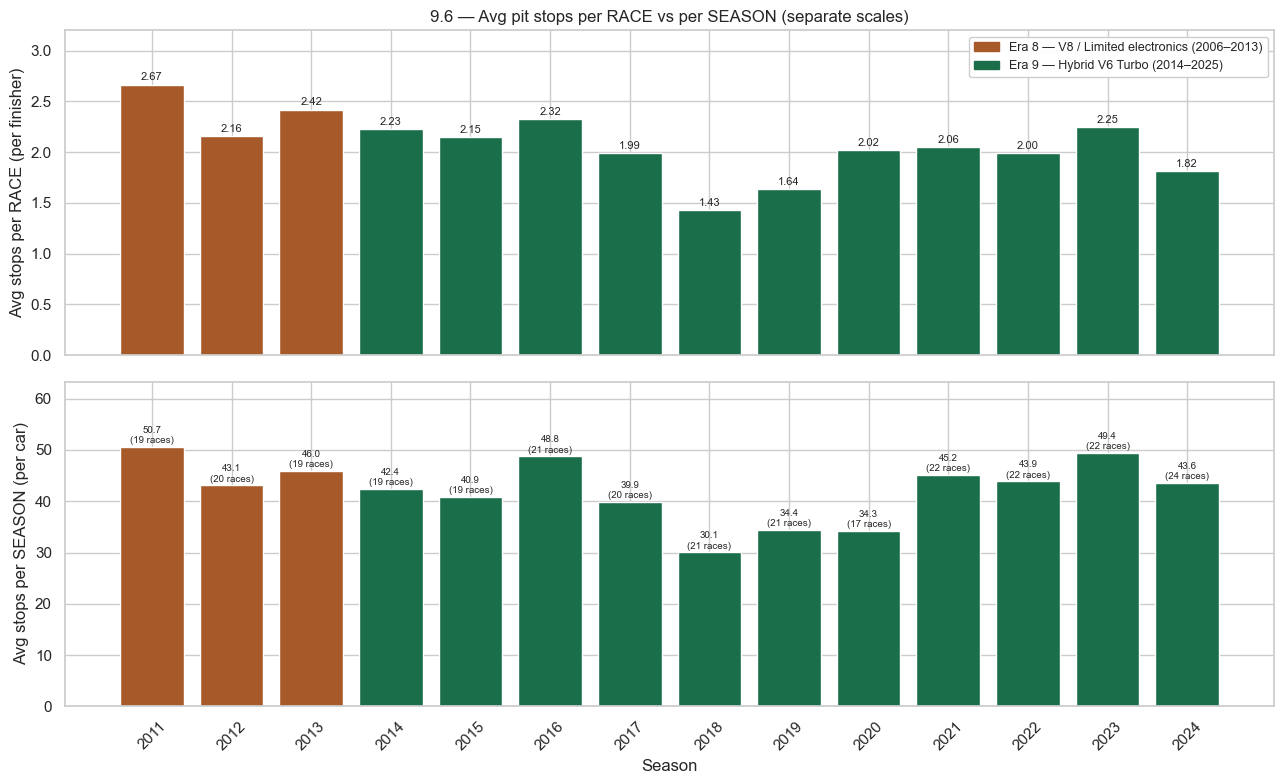

In [29]:
races_per_year = (races[races['year'] >= 2011]
                  .groupby('year').size().reset_index(name='races'))

per_year_strategy = (per_season.merge(races_per_year, on='year'))
per_year_strategy['stops_per_season'] = (per_year_strategy['avg_stops']
                                         * per_year_strategy['races'])
per_year_strategy['era_id'] = per_year_strategy['year'].apply(year_to_era)

print('Per-race vs per-season pit stop counts:')
print(per_year_strategy.round(2).to_string(index=False))


# Two separate panels (NOT a twin-axis chart). A twinx() plot lets two unrelated
# scales share x and tricks the eye into seeing "correlation" between bars and
# the line. Stacking them with independent y-axes makes both signals honest.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

bar_colors = [ERA_COLORS[e] for e in per_year_strategy['era_id']]

# Top: per-race
ax1.bar(per_year_strategy['year'], per_year_strategy['avg_stops'],
        color=bar_colors, edgecolor='white')
for r in per_year_strategy.itertuples():
    ax1.text(r.year, r.avg_stops + 0.04,
             f'{r.avg_stops:.2f}', ha='center', fontsize=8)
ax1.set_ylabel('Avg stops per RACE (per finisher)')
ax1.set_title('9.6 — Avg pit stops per RACE vs per SEASON (separate scales)')
ax1.set_ylim(0, per_year_strategy['avg_stops'].max() * 1.20)

# Bottom: per-season
ax2.bar(per_year_strategy['year'], per_year_strategy['stops_per_season'],
        color=bar_colors, edgecolor='white')
for r in per_year_strategy.itertuples():
    ax2.text(r.year, r.stops_per_season + 0.7,
             f'{r.stops_per_season:.1f}\n({r.races} races)',
             ha='center', fontsize=7)
ax2.set_ylabel('Avg stops per SEASON (per car)')
ax2.set_xlabel('Season')
ax2.set_ylim(0, per_year_strategy['stops_per_season'].max() * 1.25)

# Per-year x-ticks
ax2.set_xticks(per_year_strategy['year'])
ax2.set_xticklabels(per_year_strategy['year'], rotation=45)

# Era legend
eras_in_chart = (per_year_strategy.merge(eras_df, on='era_id')
                 [['era_id', 'name_en', 'year_start', 'year_end']]
                 .drop_duplicates().sort_values('era_id'))
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=ERA_COLORS[r.era_id],
                                label=f'Era {r.era_id} — {r.name_en} ({r.year_start}–{r.year_end})')
                  for r in eras_in_chart.itertuples()]
ax1.legend(handles=legend_handles, loc='upper right', fontsize=9, framealpha=0.95)

plt.tight_layout()
show_and_save('9.6_per_race_vs_per_season.png')

**SQL equivalent** — combine 9.1's per-race average with `COUNT(*) FROM races` per year and multiply.
```sql
SELECT  py.year,
        py.avg_stops_per_race,
        rpy.races_in_season,
        py.avg_stops_per_race * rpy.races_in_season AS avg_stops_per_season
FROM    /* 9.1 query as py */ ,
        (SELECT year, COUNT(*) AS races_in_season FROM races GROUP BY year) rpy
WHERE   py.year = rpy.year;
```


---
### 9.7 — Average pit-stop time per circuit *(top 5 highest & lowest, 2011+)*

`pit_stops.milliseconds` measures the **stationary time at the box** (jacks down → jacks up), NOT the full pit-lane traverse you see on TV. So this chart reflects **crew speed under that circuit's conditions**, not pit-lane length.

**Data caveats — read these first:**
1. **Coverage starts 2011** — Ergast doesn't have pit-stop times before that. This is a modern-era-only chart.
2. **Outliers matter a lot.** A 60+ second "stop" almost always means a mechanical repair, not a pit stop. Filter: only count stops < 60 seconds.
3. **Median, not mean.** A handful of slow stops would wreck the mean; median is robust to outliers.
4. **Min 5 stops** per circuit.

**Why the variation per circuit?** Different reasons across the ranking:
- **Slow circuits** (Singapore, Imola, Sochi) — narrow pit lanes, traffic, races prone to safety cars that bunch up pit traffic
- **Fast circuits** (Hockenheim, Zandvoort, Baku) — modern pit boxes, smooth crew operations, less SC chaos

Total stop time = stationary time + pit-lane traverse. We only measure the *stationary* portion, so this is really a "crew efficiency under circuit traffic conditions" ranking.

Pit stops retained: 10,854 of 11,371 (dropped 517 repair/anomaly stops > 60s)

9.7 — Top 5 circuits with HIGHEST median pit-stop time (2011+, ≥5 stops):
                      circuit   country  stops  median_s    mean_s  first_year  last_year
          Circuit Paul Ricard    France     90   30.7895 31.927511        2018       2022
Autodromo Enzo e Dino Ferrari     Italy    116   30.5900 32.680776        2020       2024
               Sochi Autodrom    Russia    196   30.1840 31.298526        2014       2021
            Marina Bay Street Singapore    541   29.9220 30.400832        2011       2024
                  Silverstone        UK    521   28.7190 28.880727        2011       2024

9.7 — Top 5 circuits with LOWEST median pit-stop time (2011+, ≥5 stops):
               circuit     country  stops  median_s    mean_s  first_year  last_year
        Hockenheimring     Germany    292   19.8340 20.650318        2012       2019
Circuit Park Zandvoort Netherlands    211   20.2130 21.593815  

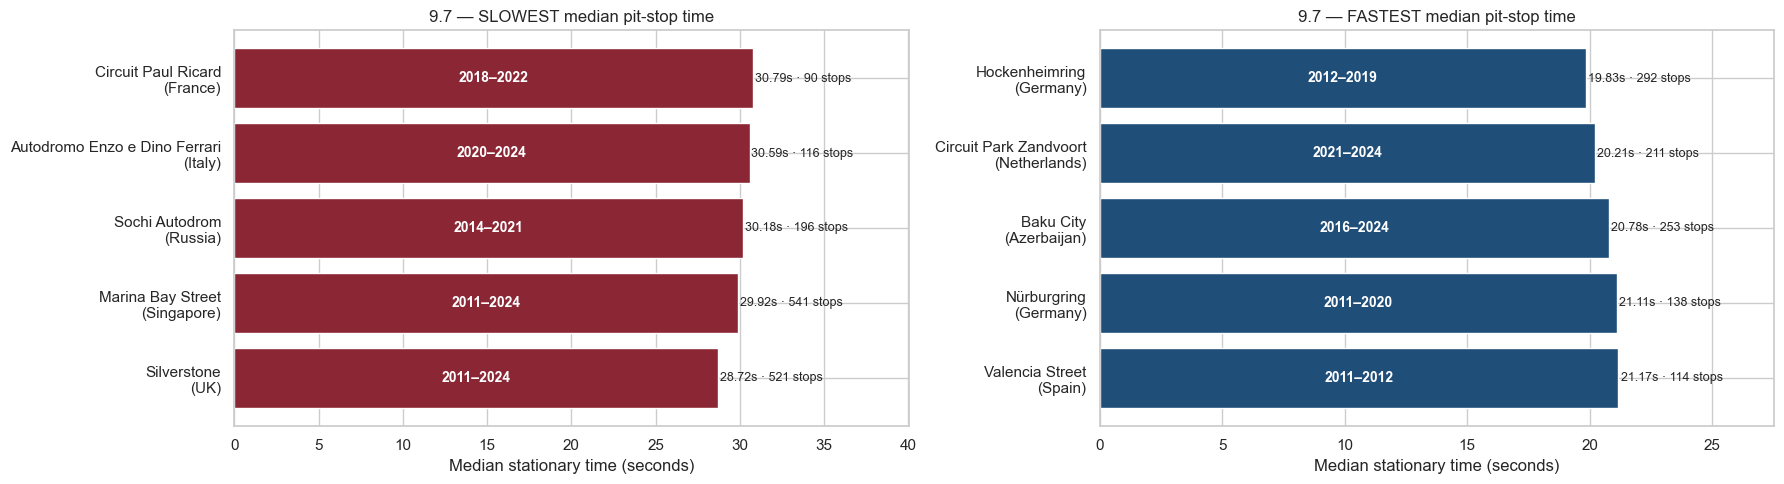

In [30]:
# Build a per-circuit join — circuits table isn't loaded in setup, so load it here
circuits = pd.read_csv('excel/circuits.csv')
circuits['circuit'] = circuits['name'].str.replace(' Circuit', '', regex=False)
race_circuit = races.merge(circuits[['circuitId', 'circuit', 'country']], on='circuitId')

# Re-derive a raw (all-stops) seconds frame — the notebook's `ps_finishers` is
# restricted to finishers, but for crew-speed we want every recorded stop.
pit_stops_full = pit_stops.copy()
pit_stops_full['seconds'] = pit_stops_full['milliseconds'].astype(float) / 1000

# Cleanup: drop stops > 60s (mechanical repairs, not real stops)
pit_clean = pit_stops_full[pit_stops_full['seconds'] < 60].copy()
print(f'Pit stops retained: {len(pit_clean):,} of {len(pit_stops_full):,} '
      f'(dropped {len(pit_stops_full)-len(pit_clean):,} repair/anomaly stops > 60s)')

pit_with_circuit = pit_clean.merge(race_circuit[['raceId', 'circuit', 'country', 'year']],
                                    on='raceId')

per_circuit_pit = (pit_with_circuit.groupby(['circuit', 'country'])
                   .agg(stops=('seconds', 'count'),
                        median_s=('seconds', 'median'),
                        mean_s=('seconds', 'mean'),
                        first_year=('year', 'min'),
                        last_year=('year', 'max'))
                   .reset_index())
per_circuit_pit = per_circuit_pit[per_circuit_pit['stops'] >= 5]

slowest = per_circuit_pit.nlargest(5, 'median_s')
fastest = per_circuit_pit.nsmallest(5, 'median_s')

print('\n9.7 — Top 5 circuits with HIGHEST median pit-stop time (2011+, ≥5 stops):')
print(slowest.to_string(index=False))
print('\n9.7 — Top 5 circuits with LOWEST median pit-stop time (2011+, ≥5 stops):')
print(fastest.to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(18, 5))

for ax, df, title, color in [
    (axes[0], slowest.sort_values('median_s'),
     '9.7 — SLOWEST median pit-stop time', '#8B2635'),
    (axes[1], fastest.sort_values('median_s', ascending=False),
     '9.7 — FASTEST median pit-stop time', '#1F4E79'),
]:
    ax.barh(range(len(df)), df['median_s'], color=color, edgecolor='white')
    ax.set_yticks(range(len(df)))
    ax.set_yticklabels([f'{c}\n({k})' for c, k in zip(df['circuit'], df['country'])])
    for i, row in enumerate(df.itertuples()):
        ax.text(row.median_s + 0.1, i,
                f'{row.median_s:.2f}s · {int(row.stops)} stops',
                va='center', fontsize=9)
        ax.text(row.median_s * 0.5, i,
                f'{int(row.first_year)}–{int(row.last_year)}',
                va='center', ha='center', fontsize=10, color='white', fontweight='bold')
    ax.set_title(title)
    ax.set_xlabel('Median stationary time (seconds)')
    ax.set_xlim(0, df['median_s'].max() * 1.30)

plt.tight_layout()
show_and_save('9.7_pit_stop_time_per_circuit.png')


**SQL equivalent**
```sql
-- 9.7: Median pit-stop stationary time per circuit (2011+, ≥5 stops, <60s)
SELECT
    c.name AS circuit, c.country,
    COUNT(*) AS stops,
    PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY p.milliseconds / 1000.0) AS median_s,
    MIN(ra.year) AS first_year, MAX(ra.year) AS last_year
FROM   pit_stops p
JOIN   races   ra ON p.raceId    = ra.raceId
JOIN   circuits c ON ra.circuitId = c.circuitId
WHERE  p.milliseconds < 60000
  AND  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY c.circuitId
HAVING COUNT(*) >= 5
ORDER  BY median_s DESC          -- ASC for fastest
LIMIT  5;
```


---
## Key insights

1. **Pit-stop data only goes back to 2011.** Every cell above silently skips the 1950–2010 window — that's a structural data limitation. The Ergast project has not back-filled it. Anyone wanting a "full F1 history" pit-stop story would need to scrape FIA archive PDFs.

2. **What `duration` actually measures.** The Ergast `duration` field looks like **total pit-lane time** (entry timing-line → exit timing-line), not the **stationary stop** that the DHL "Fastest Pit Stop" award records. That's why the *best* values here are 13–16 s, not the sub-2-second figures you'll see in news headlines. Useful caveat to flag for any reader of these charts.

3. **Mean pit-stop time is essentially flat 2011–2024** — sitting in a narrow 23–25 s band the whole time. The Hybrid era (2014+) is actually *marginally slower* on average (24.8 s) than the late-V8 era (23.4 s) — likely because of longer pit-lane speed limits and more frequent strategic-stop usage adding outliers. The team-by-team race for sub-2-second stationary stops doesn't show up in this metric.

4. **Worst stops are very long** (50 s to 100+ s) but rare — almost always a wheel-fastener issue. The cleanup filter at 120 s drops genuine retirements that were mis-coded as ultra-long stops.

5. **Stops per race vs per season (Q9.6)** stayed in narrow bands, contrary to expectations. The calendar grew (19 → 24 races) but per-race stop count drifted *down* a bit (Pirelli compound choices), so season-total stops per car stayed around 40–50.
